# 1. Imports and Setup

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# 2. Data Loading & Unified Preprocessing

In [2]:
fake = pd.read_csv("News_dataset/Fake.csv")
true = pd.read_csv("News_dataset/True.csv")

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("Label Distribution:\n", df['label'].value_counts())

df.head()

Dataset Shape: (44898, 5)
Label Distribution:
 label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [3]:
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'http\S+|www\S+', ' ', text)

    text = re.sub(r'<.*?>', ' ', text)
    
    text = re.sub(r'^.*?\(reuters\)\s*-\s*', '', text)
    text = re.sub(r'^.*?\breuters\b\s*-\s*', '', text)
    
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df['clean_text'] = df['content'].apply(clean_text)

df[['content', 'clean_text', 'label']].head()

,content,clean_text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein calls out th circuit court committed...,0
1,Trump drops Steve Bannon from National Securit...,u s president donald trump removed his chief s...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico governor ricardo rossello said on ...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump just accidentally confirmed he leak...,0
4,Donald Trump heads for Scotland to reopen a go...,most u s presidential candidates go abroad to ...,1


# 3. Train / Test Split

In [4]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 26938
Testing rows: 17960


# 4. Feature Extraction

### 1. Count Vectorizer

In [5]:
count_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=10000
)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

In [6]:
print("Training data :", X_train_count)

Training data : <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4001849 stored elements and shape (26938, 10000)>
  Coords	Values
  (0, 3534)	3
  (0, 7589)	2
  (0, 5165)	1
  (0, 8699)	1
  (0, 935)	1
  (0, 8785)	1
  (0, 8218)	2
  (0, 8822)	2
  (0, 1075)	1
  (0, 6418)	1
  (0, 6756)	2
  (0, 8041)	1
  (0, 6684)	3
  (0, 442)	1
  (0, 1894)	4
  (0, 8965)	3
  (0, 1319)	1
  (0, 1884)	1
  (0, 595)	2
  (0, 5607)	2
  (0, 3816)	1
  (0, 1508)	1
  (0, 8383)	2
  (0, 4854)	1
  (0, 5244)	2
  :	:
  (26937, 4995)	1
  (26937, 5392)	1
  (26937, 9953)	1
  (26937, 6609)	1
  (26937, 3447)	1
  (26937, 7795)	1
  (26937, 3366)	1
  (26937, 6996)	1
  (26937, 7540)	1
  (26937, 1628)	1
  (26937, 4662)	1
  (26937, 1110)	1
  (26937, 8550)	1
  (26937, 7752)	2
  (26937, 5087)	1
  (26937, 714)	1
  (26937, 2638)	1
  (26937, 189)	1
  (26937, 5088)	1
  (26937, 2497)	1
  (26937, 1830)	1
  (26937, 8763)	1
  (26937, 2665)	2
  (26937, 3724)	1
  (26937, 1447)	3


### 2. Word2Vec

In [7]:
train_words = X_train.str.split()
test_words = X_test.str.split()

w2v_model = Word2Vec(
    sentences=train_words.tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    epochs=15,
    seed=42
)

def get_average_vector(words, model):
    word_vectors = []
    for w in words:
        if w in model.wv:
            word_vectors.append(model.wv[w])
            
    if len(word_vectors) == 0:
        return np.zeros(100)
    
    return np.mean(word_vectors, axis=0)

X_train_w2v_list = []
for words in train_words:
    vec = get_average_vector(words, w2v_model)
    X_train_w2v_list.append(vec)
X_train_w2v = np.array(X_train_w2v_list)


X_test_w2v_list = []
for words in test_words:
    vec = get_average_vector(words, w2v_model)
    X_test_w2v_list.append(vec)
X_test_w2v = np.array(X_test_w2v_list)

print("Vocabulary size    :", len(w2v_model.wv))

Vocabulary size    : 60229


In [8]:
print("Training data :", X_train_w2v)

Training data : [[-0.15252279 -0.07846969  0.63187557 ...  0.08942923  0.31752187
  -0.27626616]
 [-0.25162712  0.1296957   0.59675252 ... -0.31343466  0.59588706
  -0.94075161]
 [-0.01695804  0.28129163  0.91245198 ... -0.22898914  0.62111932
  -0.59050316]
 ...
 [-0.1783745   0.32971546  1.23658895 ... -0.06758508 -0.28850919
   0.12044019]
 [-0.10237044 -0.02335514  0.56336844 ...  0.17621435  0.46998602
  -0.07495178]
 [-0.02347006 -0.32375029  0.16111584 ... -0.43524018  0.74747914
  -0.68296134]]


### 3. TF-IDF Vectorizer

In [9]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=10000,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [10]:
print("Training data :", X_train_tfidf)

Training data : <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4001849 stored elements and shape (26938, 10000)>
  Coords	Values
  (0, 3534)	0.14358217839202622
  (0, 7589)	0.08869658554853753
  (0, 5165)	0.04722694463137909
  (0, 8699)	0.0730360378690963
  (0, 935)	0.08787909570244616
  (0, 8785)	0.07596045691491433
  (0, 8218)	0.1758462392119715
  (0, 8822)	0.0937491775521806
  (0, 1075)	0.08580718165050323
  (0, 6418)	0.05131684841404235
  (0, 6756)	0.135621303417091
  (0, 8041)	0.06333207051700511
  (0, 6684)	0.14965881258290406
  (0, 442)	0.0599827463613389
  (0, 1894)	0.11346937423921612
  (0, 8965)	0.09072663930659122
  (0, 1319)	0.06539262007501652
  (0, 1884)	0.09035760846527834
  (0, 595)	0.12466683427609454
  (0, 5607)	0.12269253885462915
  (0, 3816)	0.08511867587700776
  (0, 1508)	0.07744317271943484
  (0, 8383)	0.17277843870632584
  (0, 4854)	0.0804674387361574
  (0, 5244)	0.1428219603257866
  :	:
  (26937, 4995)	0.07207792444085519
  (26937, 5392)	0.0772074

# 5. Model Training & Evaluation

In [11]:
results = []

def evaluate_model(model, name, X_tr, X_te):
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results.append({'Model': name, 'Accuracy': acc, 'F1 Score': f1})
    return preds

### Naive Bayes

In [12]:
evaluate_model(MultinomialNB(), 'Naïve Bayes (Count)', X_train_count, X_test_count)
evaluate_model(MultinomialNB(), 'Naïve Bayes (TF-IDF)', X_train_tfidf, X_test_tfidf)
evaluate_model(GaussianNB(), 'Naïve Bayes (Word2Vec)', X_train_w2v, X_test_w2v)

array([1, 0, 0, ..., 0, 0, 1], shape=(17960,))

### SVM

In [13]:
evaluate_model(LinearSVC(C=1.0, max_iter=5000), 'LinearSVC (Count)', X_train_count, X_test_count)
svm_tfidf_preds = evaluate_model(LinearSVC(C=1.0, max_iter=5000), 'LinearSVC (TF-IDF)', X_train_tfidf, X_test_tfidf)
evaluate_model(LinearSVC(C=1.0, max_iter=5000), 'LinearSVC (Word2Vec)', X_train_w2v, X_test_w2v)

array([1, 0, 0, ..., 0, 0, 1], shape=(17960,))

### Random Forest

In [14]:
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth = 50), 'Random Forest (Count)', X_train_count, X_test_count)
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth = 50), 'Random Forest (TF-IDF)', X_train_tfidf, X_test_tfidf)
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth = 50), 'Random Forest (Word2Vec)', X_train_w2v, X_test_w2v)

array([1, 0, 0, ..., 0, 0, 1], shape=(17960,))

# 6. Final Results Comparison

In [15]:
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
print("\nAll Models Performance Comparison:")
results_df


All Models Performance Comparison:


,Model,Accuracy,F1 Score
0,LinearSVC (TF-IDF),0.991648,0.991257
1,LinearSVC (Count),0.986637,0.986004
2,Random Forest (TF-IDF),0.985690,0.985082
3,Random Forest (Count),0.985356,0.984747
4,LinearSVC (Word2Vec),0.967316,0.965898
5,Random Forest (Word2Vec),0.962472,0.960571
6,Naïve Bayes (Count),0.955122,0.952970
7,Naïve Bayes (TF-IDF),0.953341,0.951166
8,Naïve Bayes (Word2Vec),0.898497,0.896614


# 7. Classification Report & Confusion Matrix (Top Performer: LinearSVC TF-IDF)


Classification Report (LinearSVC + TF-IDF):
              precision    recall  f1-score   support

   Fake News       0.99      0.99      0.99      9393
   True News       0.99      0.99      0.99      8567

    accuracy                           0.99     17960
   macro avg       0.99      0.99      0.99     17960
weighted avg       0.99      0.99      0.99     17960



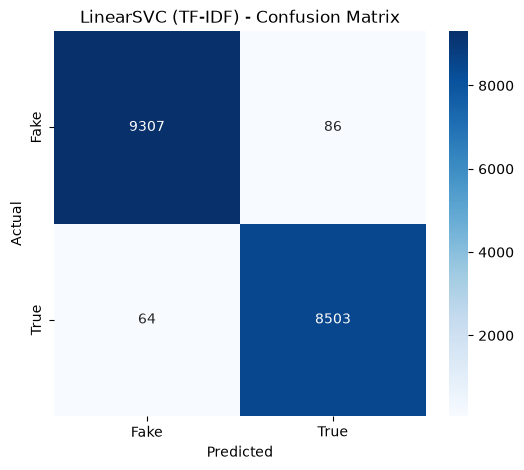

In [16]:
print("\nClassification Report (LinearSVC + TF-IDF):")
print(classification_report(y_test, svm_tfidf_preds, target_names=["Fake News", "True News"]))

cm = confusion_matrix(y_test, svm_tfidf_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
plt.title("LinearSVC (TF-IDF) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 8. Visualizations

C:\Users\user\AppData\Local\Temp\ipykernel_15452\4170055631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='F1 Score', y='Model', palette='viridis')


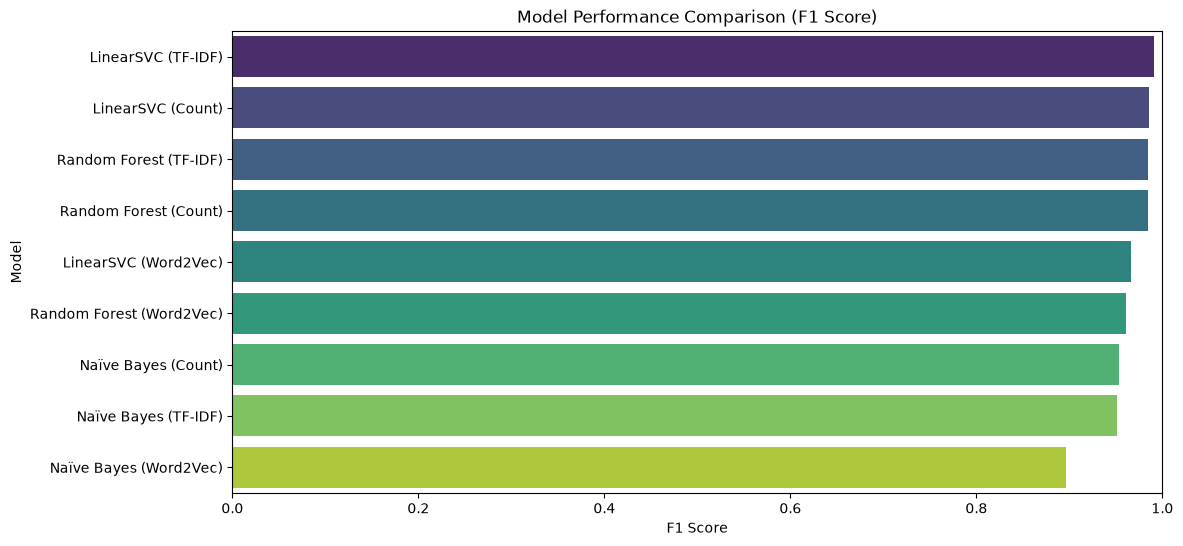

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df, 
    x='F1 Score', 
    y='Model', 
    hue='Model', 
    palette='viridis', 
    legend=False
)
plt.title('Model Performance Comparison (F1 Score)')
plt.xlim(0, 1.0)
plt.show()

# 9. External Dataset Validation

In [18]:
ext_df = pd.read_csv('News_dataset/WELFake_Dataset_10.csv')
ext_df['content'] = ext_df['title'].fillna('') + ' ' + ext_df['text'].fillna('')
ext_df['clean_text'] = ext_df['content'].apply(clean_text)

X_ext = ext_df['clean_text']
y_ext = 1 - ext_df['label']

print("External Dataset Size:", len(X_ext))

X_ext_count = count_vectorizer.transform(X_ext)
X_ext_tfidf = tfidf_vectorizer.transform(X_ext)

ext_words = X_ext.str.split()

X_ext_w2v_list = []
for words in ext_words:
    vec = get_average_vector(words, w2v_model)
    X_ext_w2v_list.append(vec)
X_ext_w2v = np.array(X_ext_w2v_list)
ext_results = []

def evaluate_on_external(model, name, X_tr, X_te_ext):
    model.fit(X_tr, y_train)
    preds = model.predict(X_te_ext)
    acc = accuracy_score(y_ext, preds)
    f1 = f1_score(y_ext, preds)
    ext_results.append({'Model': name, 'Accuracy': acc, 'F1 Score': f1})
    return preds

# Naive Bayes
evaluate_on_external(MultinomialNB(), 'Naïve Bayes (Count)', X_train_count, X_ext_count)
evaluate_on_external(MultinomialNB(), 'Naïve Bayes (TF-IDF)', X_train_tfidf, X_ext_tfidf)
evaluate_on_external(GaussianNB(), 'Naïve Bayes (Word2Vec)', X_train_w2v, X_ext_w2v)

# SVM
evaluate_on_external(LinearSVC(C=1.0, max_iter=5000), 'LinearSVC (Count)', X_train_count, X_ext_count)
svm_ext_tfidf_preds = evaluate_on_external(LinearSVC(C=1.0, max_iter=5000), 'LinearSVC (TF-IDF)', X_train_tfidf, X_ext_tfidf)
evaluate_on_external(LinearSVC(C=1.0, max_iter=5000), 'LinearSVC (Word2Vec)', X_train_w2v, X_ext_w2v)

# Random Forest
evaluate_on_external(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth = 50), 'Random Forest (Count)', X_train_count, X_ext_count)
evaluate_on_external(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth = 50), 'Random Forest (TF-IDF)', X_train_tfidf, X_ext_tfidf)
evaluate_on_external(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth = 50), 'Random Forest (Word2Vec)', X_train_w2v, X_ext_w2v)

ext_results_df = pd.DataFrame(ext_results).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
print("\nExternal Dataset - All 9 Models Performance Comparison:")
display(ext_results_df)

# -------------------------------------------------------------------

best_model_row = ext_results_df.loc[ext_results_df['F1 Score'].idxmax()]
print("\nBest performing model on external dataset:\n", best_model_row['Model'])
print("Accuracy :", best_model_row['Accuracy'])
print("F1 Score :", best_model_row['F1 Score'])

External Dataset Size: 10000

External Dataset - All 9 Models Performance Comparison:


,Model,Accuracy,F1 Score
0,Random Forest (TF-IDF),0.8489,0.833020
1,Random Forest (Count),0.8464,0.830538
2,LinearSVC (Word2Vec),0.8392,0.820736
3,Random Forest (Word2Vec),0.8353,0.816694
4,LinearSVC (TF-IDF),0.8384,0.815693
5,LinearSVC (Count),0.8346,0.812174
6,Naïve Bayes (Count),0.8042,0.781765
7,Naïve Bayes (TF-IDF),0.8029,0.781316
8,Naïve Bayes (Word2Vec),0.7676,0.753186



Best performing model on external dataset:
 Random Forest (TF-IDF)
Accuracy : 0.8489
F1 Score : 0.8330202232290861
